# Introduction
Managing personal finances effectively is a critical skill for consumers. Understanding where money is spent, which categories dominate spending, and monthly trends can help individuals budget better, optimize expenses, and save for the future.

This project leverages a Personal Budget Transactions dataset containing real-life consumer transaction records, including:

Transaction dates
Categories (e.g., restaurants, markets, coffee)
Transaction amounts

The goal is to analyze spending patterns and generate insights and recommendations for consumers, presented through an interactive Streamlit dashboard.

# Objectives

The main objectives of this project are:

**Data Understanding & Cleaning:**
Inspect the dataset for missing values, duplicates, and incorrect entries
Convert data types to ensure accurate analysis

**Spending Analysis:**
Identify the most common and highest spending categories
Track monthly trends to detect peaks and seasonal patterns
Compute average spending per category

**Insight Generation & Recommendations:**
Highlight consumer spending behavior
Suggest ways to optimize budgets and manage expenses

**Interactive Dashboard (Streamlit):**
Enable users to visualize spending trends
Provide interactive charts and tables to explore the data

# Dataset description

| Column     | Description                                    |
| ---------- | ---------------------------------------------- |
| `date`     | Date of the transaction                        |
| `category` | Spending category (e.g., restaurants, markets) |
| `amount`   | Transaction amount in USD                      |


This dataset is suitable for:

Financial analysis and consumer insights
Time series analysis (monthly spending trends)
Visualization for interactive dashboards

In [2]:
import sys
print(sys.executable)

c:\anaconda3\python.exe


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("budget_data.csv")

# Preview first few rows
df.head()

,date,category,amount
0,2022-07-06 05:57:10 +0000,Restuarant,5.50
1,2022-07-06 05:57:27 +0000,Market,2.00
2,2022-07-06 05:58:12 +0000,Coffe,30.10
3,2022-07-06 05:58:25 +0000,Market,17.33
4,2022-07-06 05:59:00 +0000,Restuarant,5.50


In [4]:
df.shape

(3608, 3)

In [5]:
# Convert to datetime and parse timezone
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')

# Drop rows where conversion failed (if any)
df = df.dropna(subset=['date'])

# Optional: remove timezone info to make analysis simpler
df['date'] = df['date'].dt.tz_convert(None)

In [6]:
print(df['date'].head())
print(df['date'].dtype)

0   2022-07-06 05:57:10
1   2022-07-06 05:57:27
2   2022-07-06 05:58:12
3   2022-07-06 05:58:25
4   2022-07-06 05:59:00
Name: date, dtype: datetime64[ns]
datetime64[ns]


In [7]:

df['date'].dtype
# datetime64[ns]

dtype('<M8[ns]')

### **Feature Engineering**

In [8]:
# Weekday name
df['day'] = df['date'].dt.day_name()

# Only date (YYYY-MM-DD)
df['only_date'] = df['date'].dt.date

# Time
df['time'] = df['date'].dt.time

# Assuming 'date' column is datetime64[ns]
df['month'] = df['date'].dt.month_name()

df['month_num'] = df['date'].dt.month

df['hour'] = df['date'].dt.hour


In [9]:
df.head()

,date,category,amount,day,only_date,time,month,month_num,hour
0,2022-07-06 05:57:10,Restuarant,5.50,Wednesday,2022-07-06,05:57:10,July,7,5
1,2022-07-06 05:57:27,Market,2.00,Wednesday,2022-07-06,05:57:27,July,7,5
2,2022-07-06 05:58:12,Coffe,30.10,Wednesday,2022-07-06,05:58:12,July,7,5
3,2022-07-06 05:58:25,Market,17.33,Wednesday,2022-07-06,05:58:25,July,7,5
4,2022-07-06 05:59:00,Restuarant,5.50,Wednesday,2022-07-06,05:59:00,July,7,5


In [10]:
# Rename 'date' -> 'date_time', 'only_date' -> 'date'
df = df.rename(columns={'date': 'date_time', 'only_date': 'date'})

In [11]:
df.head()

,date_time,category,amount,day,date,time,month,month_num,hour
0,2022-07-06 05:57:10,Restuarant,5.50,Wednesday,2022-07-06,05:57:10,July,7,5
1,2022-07-06 05:57:27,Market,2.00,Wednesday,2022-07-06,05:57:27,July,7,5
2,2022-07-06 05:58:12,Coffe,30.10,Wednesday,2022-07-06,05:58:12,July,7,5
3,2022-07-06 05:58:25,Market,17.33,Wednesday,2022-07-06,05:58:25,July,7,5
4,2022-07-06 05:59:00,Restuarant,5.50,Wednesday,2022-07-06,05:59:00,July,7,5


In [12]:
# Info and types
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3608 entries, 0 to 3607
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date_time  3608 non-null   datetime64[ns]
 1   category   3608 non-null   object        
 2   amount     3608 non-null   float64       
 3   day        3608 non-null   object        
 4   date       3608 non-null   object        
 5   time       3608 non-null   object        
 6   month      3608 non-null   object        
 7   month_num  3608 non-null   int32         
 8   hour       3608 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(2), object(5)
memory usage: 225.6+ KB


In [13]:
# Basic statistics for numeric columns
df.describe()


,date_time,amount,month_num,hour
count,3608,3608.000000,3608.000000,3608.000000
mean,2023-08-22 22:44:11.544068864,17.130241,6.761641,11.549612
min,2022-07-06 05:57:10,0.050000,1.000000,0.000000
25%,2023-01-21 08:58:24.249999872,4.800000,4.000000,8.000000
50%,2023-08-02 23:23:59,7.100000,7.000000,12.000000
75%,2024-04-17 05:43:32.750000128,11.505000,9.000000,15.000000
max,2024-09-29 10:40:38,2500.000000,12.000000,23.000000
std,NaN,84.946260,3.263453,4.745158


In [14]:

# Missing values
df.isnull().sum()



date_time    0
category     0
amount       0
day          0
date         0
time         0
month        0
month_num    0
hour         0
dtype: int64

In [15]:
# Unique categories
df['category'].unique()

array(['Restuarant', 'Market', 'Coffe', 'Transport', 'Other', 'Phone',
       'Communal', 'Clothing', 'Motel', 'Travel', 'Rent Car', 'Sport',
       'Events', 'Learning', 'Health', 'Taxi', 'Business lunch',
       'Film/enjoyment', 'Tech', 'joy', 'Fuel', 'business_expenses'],
      dtype=object)

In [16]:
df['category'] = df['category'].str.strip()

In [17]:
# Remove duplicates and negative or zero transactions
df = df.drop_duplicates() 
df = df[df['amount'] > 0]

In [18]:
df

,date_time,category,amount,day,date,time,month,month_num,hour
0,2022-07-06 05:57:10,Restuarant,5.50,Wednesday,2022-07-06,05:57:10,July,7,5
1,2022-07-06 05:57:27,Market,2.00,Wednesday,2022-07-06,05:57:27,July,7,5
2,2022-07-06 05:58:12,Coffe,30.10,Wednesday,2022-07-06,05:58:12,July,7,5
3,2022-07-06 05:58:25,Market,17.33,Wednesday,2022-07-06,05:58:25,July,7,5
4,2022-07-06 05:59:00,Restuarant,5.50,Wednesday,2022-07-06,05:59:00,July,7,5
...,...,...,...,...,...,...,...,...,...
3603,2024-09-28 13:31:37,Market,8.00,Saturday,2024-09-28,13:31:37,September,9,13
3604,2024-09-29 02:57:07,Transport,0.50,Sunday,2024-09-29,02:57:07,September,9,2
3605,2024-09-29 04:29:03,Market,7.40,Sunday,2024-09-29,04:29:03,September,9,4
3606,2024-09-29 04:53:24,Coffe,15.00,Sunday,2024-09-29,04:53:24,September,9,4


In [19]:
df.to_csv("budget_data_cleaned_features.csv", index=False)

In [20]:
df_check = pd.read_csv("budget_data_cleaned_features.csv")
print(df_check.head())
print(df_check.dtypes)

             date_time    category  amount        day        date      time  \
0  2022-07-06 05:57:10  Restuarant    5.50  Wednesday  2022-07-06  05:57:10   
1  2022-07-06 05:57:27      Market    2.00  Wednesday  2022-07-06  05:57:27   
2  2022-07-06 05:58:12       Coffe   30.10  Wednesday  2022-07-06  05:58:12   
3  2022-07-06 05:58:25      Market   17.33  Wednesday  2022-07-06  05:58:25   
4  2022-07-06 05:59:00  Restuarant    5.50  Wednesday  2022-07-06  05:59:00   

  month  month_num  hour  
0  July          7     5  
1  July          7     5  
2  July          7     5  
3  July          7     5  
4  July          7     5  
date_time     object
category      object
amount       float64
day           object
date          object
time          object
month         object
month_num      int64
hour           int64
dtype: object


In [21]:
print(df['amount'].min(), df['amount'].max())

0.05 2500.0


# EDA

## **Spending Analysis**

### **1. Places where the client made the most purchases (number of transactions)**
Which categories or types of places does the client visit most frequently?

In [22]:
# Count transactions per category
category_counts = df['category'].value_counts()
print(category_counts)

category
Coffe                1043
Market                946
Restuarant            438
Business lunch        266
Transport             213
Taxi                  188
Phone                 121
Other                  78
Learning               72
Health                 46
Clothing               43
Events                 43
Communal               31
Sport                  26
joy                    13
Tech                   10
Travel                  8
Fuel                    8
business_expenses       8
Film/enjoyment          4
Rent Car                2
Motel                   1
Name: count, dtype: int64


The client made over 1000 transactions at the coffee shop

C:\Users\Rita Asemota\AppData\Local\Temp\ipykernel_35260\3387000562.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette="viridis")


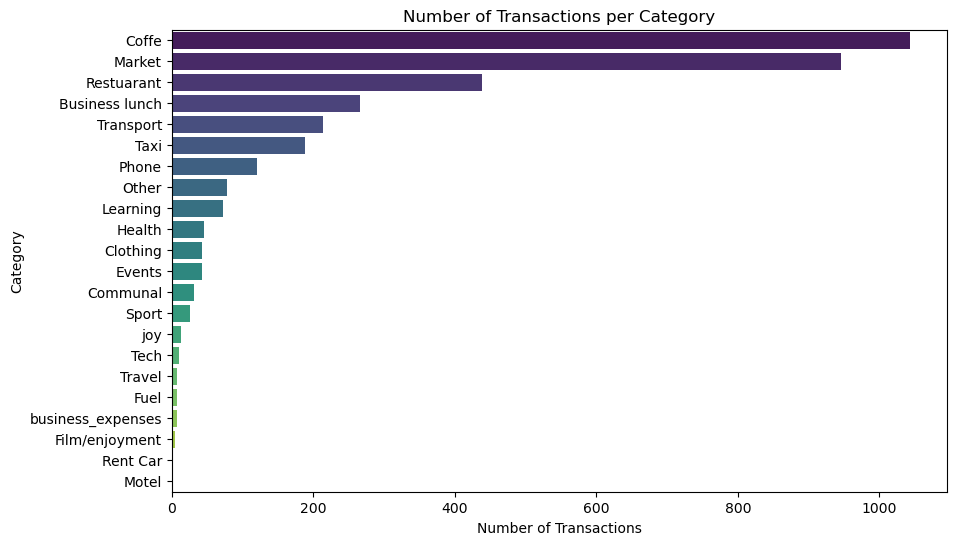

In [23]:
# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=category_counts.values, y=category_counts.index, palette="viridis")
plt.title("Number of Transactions per Category")
plt.xlabel("Number of Transactions")
plt.ylabel("Category")
plt.show()

### **2. Places where the client spent the most money**

Which categories or places account for the highest total spending. That is, what the client spends lots of money on?

category
Restuarant           10425.60
Coffe                 9350.70
Market                6451.03
Health                5896.50
Clothing              4365.50
Communal              4192.50
Travel                3756.45
Tech                  2985.00
Events                2751.30
Learning              2525.31
Business lunch        2503.01
Sport                 1436.76
Other                 1045.75
Taxi                   865.08
Transport              746.70
Motel                  675.00
Phone                  666.08
joy                    524.30
business_expenses      400.00
Fuel                   114.00
Rent Car                95.00
Film/enjoyment          34.34
Name: amount, dtype: float64


C:\Users\Rita Asemota\AppData\Local\Temp\ipykernel_35260\801651632.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sum.values, y=category_sum.index, palette="magma")


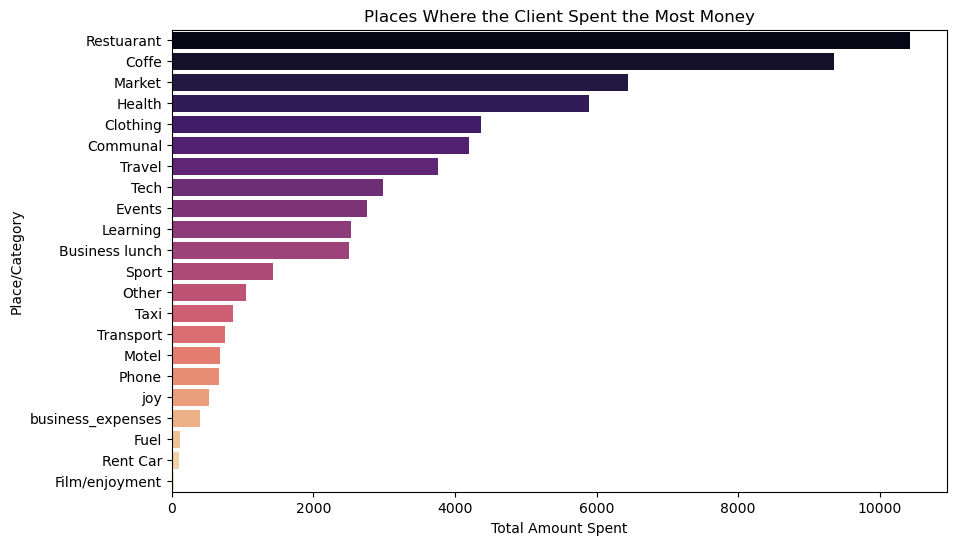

In [24]:
category_sum = df.groupby('category')['amount'].sum().sort_values(ascending=False)
print(category_sum)

plt.figure(figsize=(10,6))
sns.barplot(x=category_sum.values, y=category_sum.index, palette="magma")
plt.title("Places Where the Client Spent the Most Money")
plt.xlabel("Total Amount Spent")
plt.ylabel("Place/Category")
plt.show()

### **3. Average spending per visit per place**

On average, how much does the client spend per visit in each category?

This isb the second analysis dividedd by the first analysis

category
Motel                675.000000
Travel               469.556250
Tech                 298.500000
Communal             135.241935
Health               128.184783
Clothing             101.523256
Events                63.983721
Sport                 55.260000
business_expenses     50.000000
Rent Car              47.500000
joy                   40.330769
Learning              35.073750
Restuarant            23.802740
Fuel                  14.250000
Other                 13.407051
Business lunch         9.409812
Coffe                  8.965197
Film/enjoyment         8.585000
Market                 6.819271
Phone                  5.504793
Taxi                   4.601489
Transport              3.505634
Name: amount, dtype: float64


C:\Users\Rita Asemota\AppData\Local\Temp\ipykernel_35260\683323435.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_avg.values, y=category_avg.index, palette="coolwarm")


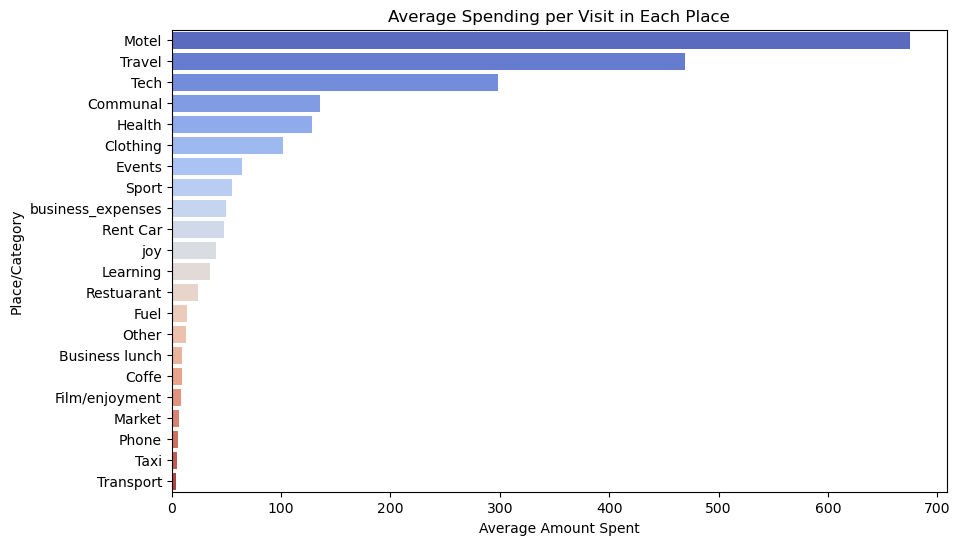

In [25]:
category_avg = df.groupby('category')['amount'].mean().sort_values(ascending=False)
print(category_avg)

plt.figure(figsize=(10,6))
sns.barplot(x=category_avg.values, y=category_avg.index, palette="coolwarm")
plt.title("Average Spending per Visit in Each Place")
plt.xlabel("Average Amount Spent")
plt.ylabel("Place/Category")
plt.show()

### **4.Monthly spending trends**

During which months does the client spend the most money
Detects peaks, seasonality, and trends in total spending per month.

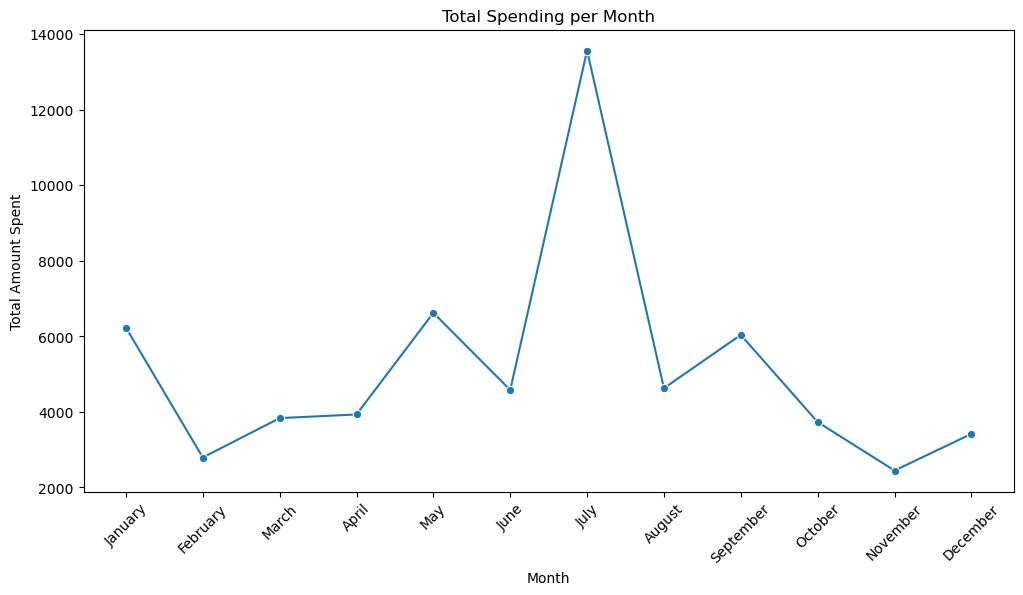

In [26]:
monthly_trend = df.groupby('month')['amount'].sum()
# Optional: sort months chronologically
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_trend = monthly_trend.reindex(month_order)



plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker='o')
plt.title("Total Spending per Month")
plt.xlabel("Month")
plt.ylabel("Total Amount Spent")
plt.xticks(rotation=45)
plt.show()

Client spent more in July.

Further analysis to figure out what exactly was bought in July since the spending gap was high

In [27]:
monthly_trend

month
January       6231.12
February      2791.50
March         3833.79
April         3931.18
May           6621.38
June          4579.38
July         13563.59
August        4625.80
September     6036.70
October       3729.38
November      2446.12
December      3415.97
Name: amount, dtype: float64

In [28]:
# Filter dataset for July
july_data = df[df['month'] == 'July']

# Check first few rows
july_data

,date_time,category,amount,day,date,time,month,month_num,hour
0,2022-07-06 05:57:10,Restuarant,5.50,Wednesday,2022-07-06,05:57:10,July,7,5
1,2022-07-06 05:57:27,Market,2.00,Wednesday,2022-07-06,05:57:27,July,7,5
2,2022-07-06 05:58:12,Coffe,30.10,Wednesday,2022-07-06,05:58:12,July,7,5
3,2022-07-06 05:58:25,Market,17.33,Wednesday,2022-07-06,05:58:25,July,7,5
4,2022-07-06 05:59:00,Restuarant,5.50,Wednesday,2022-07-06,05:59:00,July,7,5
...,...,...,...,...,...,...,...,...,...
3231,2024-07-31 09:11:32,Learning,3.00,Wednesday,2024-07-31,09:11:32,July,7,9
3232,2024-07-31 09:41:41,Business lunch,11.00,Wednesday,2024-07-31,09:41:41,July,7,9
3233,2024-07-31 12:07:24,Phone,10.00,Wednesday,2024-07-31,12:07:24,July,7,12
3234,2024-07-31 12:19:51,Phone,5.00,Wednesday,2024-07-31,12:19:51,July,7,12


Total spending per category in July:
 category
Travel               3493.25
Tech                 2272.00
Clothing             1866.50
Restuarant           1172.15
Coffe                 835.55
Events                791.00
Motel                 675.00
Market                628.65
Communal              529.00
Business lunch        316.59
Taxi                  167.50
business_expenses     150.00
Sport                 109.00
Learning              102.40
Transport             100.60
Rent Car               95.00
Phone                  78.00
Other                  63.40
Health                 55.00
joy                    43.00
Fuel                   20.00
Name: amount, dtype: float64


C:\Users\Rita Asemota\AppData\Local\Temp\ipykernel_35260\442879201.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=july_category_sum.values, y=july_category_sum.index, palette="magma")


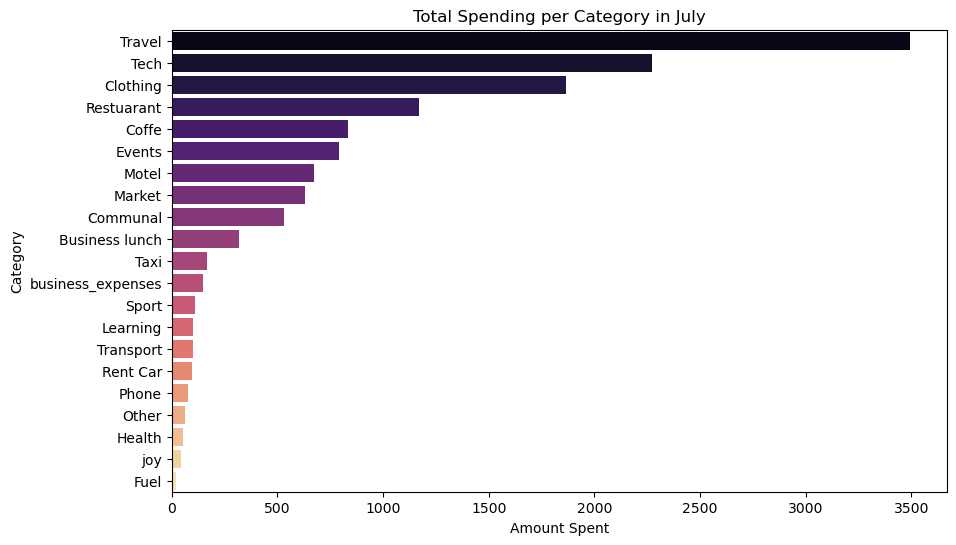

In [29]:
# Total amount spent per category in July
july_category_sum = july_data.groupby('category')['amount'].sum().sort_values(ascending=False)
print("Total spending per category in July:\n", july_category_sum)

# Optional: plot
plt.figure(figsize=(10,6))
sns.barplot(x=july_category_sum.values, y=july_category_sum.index, palette="magma")
plt.title("Total Spending per Category in July")
plt.xlabel("Amount Spent")
plt.ylabel("Category")
plt.show()

This shows that the client spent more money on travelling in July

### **5. Spending behavior across weekdays**

On which days of the week does the client tend to spend more?


C:\Users\Rita Asemota\AppData\Local\Temp\ipykernel_35260\1112495130.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_trend.index, y=weekday_trend.values, palette="summer")


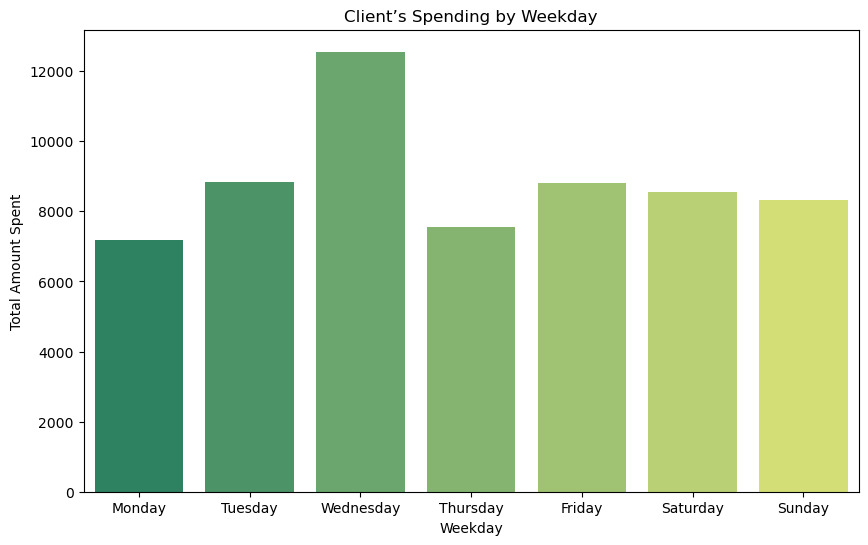

In [30]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_trend = df.groupby('day')['amount'].sum().reindex(weekday_order)

plt.figure(figsize=(10,6))
sns.barplot(x=weekday_trend.index, y=weekday_trend.values, palette="summer")
plt.title("Client’s Spending by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Total Amount Spent")
plt.show()

## **Insights Generation and Recommendations**

**1. Top 5 spending categories**

These are the categories where the client is spending the most money and may consider optimizing their budget.

In [31]:
top_spenders = category_sum.head(5)
print("Top spending categories:\n", top_spenders)

Top spending categories:
 category
Restuarant    10425.60
Coffe          9350.70
Market         6451.03
Health         5896.50
Clothing       4365.50
Name: amount, dtype: float64


Suggest cost optimization:

Highlight categories where average spend is high relative to transaction frequency.

In [32]:
# Combine frequency and average
category_analysis = pd.DataFrame({
    'total_spent': category_sum,
    'transaction_count': category_counts,
    'average_spent': category_avg
})
print(category_analysis.sort_values(by='average_spent', ascending=False))

                   total_spent  transaction_count  average_spent
category                                                        
Motel                   675.00                  1     675.000000
Travel                 3756.45                  8     469.556250
Tech                   2985.00                 10     298.500000
Communal               4192.50                 31     135.241935
Health                 5896.50                 46     128.184783
Clothing               4365.50                 43     101.523256
Events                 2751.30                 43      63.983721
Sport                  1436.76                 26      55.260000
business_expenses       400.00                  8      50.000000
Rent Car                 95.00                  2      47.500000
joy                     524.30                 13      40.330769
Learning               2525.31                 72      35.073750
Restuarant            10425.60                438      23.802740
Fuel                    1

It points out here that the main factor determining the amount the client have spent this period is the number of transactions made and not the amount of the product/service. For instance if the client is on a savings plan scheme for the next season, he/she may be recommended or advised to cut down the number of times he/she visits the restaurant or takes coffee

Detect seasonal peaks for budget planning:

Using the monthly trends plot to recommend users to set higher budgets in peak months.

### **Monthly Insights**
Useful for clients to streamline their spending habits to monthly basis on the dashboard

In [33]:
# Monthly insights summary
monthly_insights = df.groupby('month').agg(
    total_spent=('amount', 'sum'),
    transactions=('amount', 'count')
)

# Top category per month
top_category_per_month = df.groupby(['month', 'category'])['amount'].sum().reset_index()

top_category_per_month = top_category_per_month.loc[
    top_category_per_month.groupby('month')['amount'].idxmax()
]

# Merge
monthly_insights = monthly_insights.merge(
    top_category_per_month[['month', 'category']],
    on='month',
    how='left'
)

monthly_insights.rename(columns={'category': 'top_category'}, inplace=True)

print(monthly_insights)

        month  total_spent  transactions top_category
0       April      3931.18           216   Restuarant
1      August      4625.80           408        Coffe
2    December      3415.97           256        Coffe
3    February      2791.50           236        Coffe
4     January      6231.12           275       Health
5        July     13563.59           351       Travel
6        June      4579.38           318   Restuarant
7       March      3833.79           238   Restuarant
8         May      6621.38           313       Health
9    November      2446.12           271        Coffe
10    October      3729.38           290        Coffe
11  September      6036.70           436   Restuarant


In [34]:
monthly_insights.to_csv("monthly_insights.csv", index=False)